In [1]:
from __future__ import annotations

from html import unescape
from pathlib import Path
import copy
import re
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from datasets import load_from_disk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch import nn
from torch.utils.data import DataLoader, Dataset

In [2]:
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("PyTorch path:", torch.__file__)
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

Device: cuda
Python: d:\app\ai\Sentiment Analysis Traditional ML vs Transformers\.venv\Scripts\python.exe
PyTorch: 2.13.0+cu126
PyTorch path: d:\app\ai\Sentiment Analysis Traditional ML vs Transformers\.venv\Lib\site-packages\torch\__init__.py
PyTorch CUDA build: 12.6
CUDA available: True
GPU count: 1


In [3]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "imdb_clean_splits"
)

dataset = load_from_disk(str(DATA_PATH))

train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)

dataset

Train shape: (19823, 2)
Validation shape: (4956, 2)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 19823
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 4956
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
})

In [4]:
HTML_BREAK_PATTERN = re.compile(
    r"<br\s*/?>",
    flags=re.IGNORECASE,
)

HTML_TAG_PATTERN = re.compile(
    r"<[^>]+>",
)

WHITESPACE_PATTERN = re.compile(
    r"\s+",
)


def clean_text_for_model(text: str) -> str:
    """
    Apply mild formatting cleanup without changing
    the linguistic meaning of the review.
    """

    text = unescape(str(text))

    text = HTML_BREAK_PATTERN.sub(
        " ",
        text,
    )

    text = HTML_TAG_PATTERN.sub(
        " ",
        text,
    )

    text = WHITESPACE_PATTERN.sub(
        " ",
        text,
    )

    return text.strip()

In [5]:
train_texts = (
    train_df["text"]
    .map(clean_text_for_model)
    .tolist()
)

validation_texts = (
    validation_df["text"]
    .map(clean_text_for_model)
    .tolist()
)

y_train = train_df["label"].to_numpy(
    dtype=np.float32
)

y_validation = validation_df["label"].to_numpy(
    dtype=np.float32
)

print(train_texts[0][:500])
print("Label:", y_train[0])

This cool Marvel superhero game pays proper tribute by staying true to the comics. Of all the Marvel superhero games that have been so lame with weak graphics and gameplay, Spiderman improves in both departments. It also features the voice of Stan Lee, the creator of Spiderman comics. As you'd expect Spiderman does whatever a spider can. He does more than spin webs. In fact, he uses them as weapons and shields. When he's not using web in combat, he punches and kicks as well. Spidey has his hands
Label: 1.0


In [6]:
majority_label = int(
    train_df["label"].mode().iloc[0]
)

majority_predictions = np.full(
    shape=len(y_validation),
    fill_value=majority_label,
)

majority_accuracy = accuracy_score(
    y_validation,
    majority_predictions,
)

majority_f1 = f1_score(
    y_validation,
    majority_predictions,
    zero_division=0,
)

print("Majority label:", majority_label)
print(f"Majority accuracy: {majority_accuracy:.4f}")
print(f"Majority F1: {majority_f1:.4f}")

Majority label: 1
Majority accuracy: 0.5022
Majority F1: 0.6686


In [7]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95,
    max_features=20_000,
    sublinear_tf=True,
    dtype=np.float32,
)

In [8]:
start_time = time.perf_counter()

X_train = vectorizer.fit_transform(
    train_texts
)

X_validation = vectorizer.transform(
    validation_texts
)

vectorization_time = (
    time.perf_counter() - start_time
)

print("Training matrix:", X_train.shape)
print("Validation matrix:", X_validation.shape)
print("Matrix type:", type(X_train))
print(f"Vectorization time: {vectorization_time:.2f} seconds")

Training matrix: (19823, 20000)
Validation matrix: (4956, 20000)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Vectorization time: 3.23 seconds


In [9]:
total_values = (
    X_train.shape[0]
    * X_train.shape[1]
)

non_zero_values = X_train.nnz

density = (
    non_zero_values
    / total_values
)

print(f"Total possible values: {total_values:,}")
print(f"Non-zero values: {non_zero_values:,}")
print(f"Density: {density:.6%}")

Total possible values: 396,460,000
Non-zero values: 2,580,136
Density: 0.650794%


In [10]:
dense_bytes = (
    X_train.shape[0]
    * X_train.shape[1]
    * 4
)

dense_gib = dense_bytes / (1024 ** 3)

print(f"Dense matrix size: {dense_gib:.2f} GiB")

Dense matrix size: 1.48 GiB


In [11]:
class RowIndexDataset(Dataset):
    """
    Stores row indices and labels.

    The sparse feature matrix stays outside the Dataset.
    A complete mini-batch is converted to dense format
    inside the custom collate function.
    """

    def __init__(
        self,
        labels: np.ndarray,
    ) -> None:
        self.labels = np.asarray(
            labels,
            dtype=np.float32,
        )

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(
        self,
        index: int,
    ) -> tuple[int, np.float32]:
        return index, self.labels[index]

In [12]:
def create_collate_function(
    sparse_matrix,
):
    def collate_batch(batch):
        indices = np.asarray(
            [item[0] for item in batch],
            dtype=np.int64,
        )

        labels = np.asarray(
            [item[1] for item in batch],
            dtype=np.float32,
        )

        dense_features = (
            sparse_matrix[indices]
            .toarray()
            .astype(
                np.float32,
                copy=False,
            )
        )

        feature_tensor = torch.from_numpy(
            dense_features
        )

        label_tensor = torch.from_numpy(
            labels
        )

        return feature_tensor, label_tensor

    return collate_batch

In [13]:
BATCH_SIZE = 128

train_dataset = RowIndexDataset(
    y_train
)

validation_dataset = RowIndexDataset(
    y_validation
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=create_collate_function(
        X_train
    ),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=create_collate_function(
        X_validation
    ),
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(validation_loader))

Train batches: 155
Validation batches: 39


In [14]:
batch_features, batch_labels = next(
    iter(train_loader)
)

print("Feature batch shape:", batch_features.shape)
print("Label batch shape:", batch_labels.shape)
print("Feature dtype:", batch_features.dtype)
print("Label dtype:", batch_labels.dtype)

Feature batch shape: torch.Size([128, 20000])
Label batch shape: torch.Size([128])
Feature dtype: torch.float32
Label dtype: torch.float32


In [15]:
class LogisticRegressionModel(nn.Module):
    def __init__(
        self,
        number_of_features: int,
    ) -> None:
        super().__init__()

        self.linear = nn.Linear(
            in_features=number_of_features,
            out_features=1,
        )

    def forward(
        self,
        features: torch.Tensor,
    ) -> torch.Tensor:
        logits = self.linear(features)

        return logits.squeeze(dim=1)

In [16]:
model = LogisticRegressionModel(
    number_of_features=X_train.shape[1]
).to(device)

model

LogisticRegressionModel(
  (linear): Linear(in_features=20000, out_features=1, bias=True)
)

In [17]:
number_of_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    "Trainable parameters:",
    f"{number_of_parameters:,}",
)

Trainable parameters: 20,001


In [18]:
loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

In [19]:
@torch.no_grad()
def evaluate_model(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    device: torch.device,
) -> dict[str, object]:

    model.eval()

    total_loss = 0.0
    all_probabilities = []
    all_labels = []

    for features, labels in data_loader:
        features = features.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )

        logits = model(features)

        loss = loss_function(
            logits,
            labels,
        )

        probabilities = torch.sigmoid(
            logits
        )

        total_loss += (
            loss.item()
            * labels.size(0)
        )

        all_probabilities.append(
            probabilities.cpu()
        )

        all_labels.append(
            labels.cpu()
        )

    probabilities = torch.cat(
        all_probabilities
    ).numpy()

    labels = torch.cat(
        all_labels
    ).numpy().astype(int)

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    average_loss = (
        total_loss
        / len(data_loader.dataset)
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
    }

In [20]:
NUMBER_OF_EPOCHS = 8

best_validation_f1 = -1.0
best_model_state = None

training_history = []

for epoch in range(
    1,
    NUMBER_OF_EPOCHS + 1,
):
    model.train()

    total_training_loss = 0.0
    epoch_start = time.perf_counter()

    for features, labels in train_loader:
        features = features.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad()

        logits = model(features)

        loss = loss_function(
            logits,
            labels,
        )

        loss.backward()

        optimizer.step()

        total_training_loss += (
            loss.item()
            * labels.size(0)
        )

    average_training_loss = (
        total_training_loss
        / len(train_loader.dataset)
    )

    validation_results = evaluate_model(
        model=model,
        data_loader=validation_loader,
        loss_function=loss_function,
        device=device,
    )

    epoch_time = (
        time.perf_counter()
        - epoch_start
    )

    epoch_record = {
        "epoch": epoch,
        "train_loss": average_training_loss,
        "validation_loss": validation_results["loss"],
        "validation_accuracy": validation_results["accuracy"],
        "validation_precision": validation_results["precision"],
        "validation_recall": validation_results["recall"],
        "validation_f1": validation_results["f1"],
        "seconds": epoch_time,
    }

    training_history.append(
        epoch_record
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {average_training_loss:.4f} | "
        f"Val Loss: {validation_results['loss']:.4f} | "
        f"Val Accuracy: {validation_results['accuracy']:.4f} | "
        f"Val F1: {validation_results['f1']:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if (
        validation_results["f1"]
        > best_validation_f1
    ):
        best_validation_f1 = (
            validation_results["f1"]
        )

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

Epoch 01 | Train Loss: 0.6717 | Val Loss: 0.6502 | Val Accuracy: 0.8479 | Val F1: 0.8464 | Time: 1.5s
Epoch 02 | Train Loss: 0.6275 | Val Loss: 0.6128 | Val Accuracy: 0.8517 | Val F1: 0.8527 | Time: 1.4s
Epoch 03 | Train Loss: 0.5894 | Val Loss: 0.5806 | Val Accuracy: 0.8537 | Val F1: 0.8541 | Time: 1.3s
Epoch 04 | Train Loss: 0.5562 | Val Loss: 0.5527 | Val Accuracy: 0.8565 | Val F1: 0.8589 | Time: 1.5s
Epoch 05 | Train Loss: 0.5272 | Val Loss: 0.5283 | Val Accuracy: 0.8590 | Val F1: 0.8615 | Time: 1.8s
Epoch 06 | Train Loss: 0.5016 | Val Loss: 0.5068 | Val Accuracy: 0.8608 | Val F1: 0.8625 | Time: 2.0s
Epoch 07 | Train Loss: 0.4788 | Val Loss: 0.4878 | Val Accuracy: 0.8634 | Val F1: 0.8659 | Time: 1.7s
Epoch 08 | Train Loss: 0.4584 | Val Loss: 0.4708 | Val Accuracy: 0.8660 | Val F1: 0.8687 | Time: 1.6s


In [21]:
if best_model_state is None:
    raise RuntimeError(
        "No model checkpoint was saved."
    )

model.load_state_dict(
    best_model_state
)

print(
    f"Best validation F1: "
    f"{best_validation_f1:.4f}"
)

Best validation F1: 0.8687


In [22]:
history_df = pd.DataFrame(
    training_history
)

history_df

,epoch,train_loss,validation_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,seconds
0,1,0.671692,0.650163,0.847861,0.858619,0.834472,0.846373,1.508676
1,2,0.627533,0.612765,0.851695,0.850800,0.854560,0.852676,1.355298
2,3,0.589368,0.580579,0.853713,0.855645,0.852551,0.854095,1.288990
3,4,0.556184,0.552662,0.856538,0.848627,0.869425,0.858901,1.472842
4,5,0.527165,0.528273,0.858959,0.849883,0.873443,0.861502,1.848458
5,6,0.501594,0.506803,0.860775,0.855393,0.869827,0.862550,2.010289
6,7,0.478801,0.487752,0.863398,0.853906,0.878264,0.865914,1.704361
7,8,0.458434,0.470805,0.866021,0.855197,0.882684,0.868723,1.623457


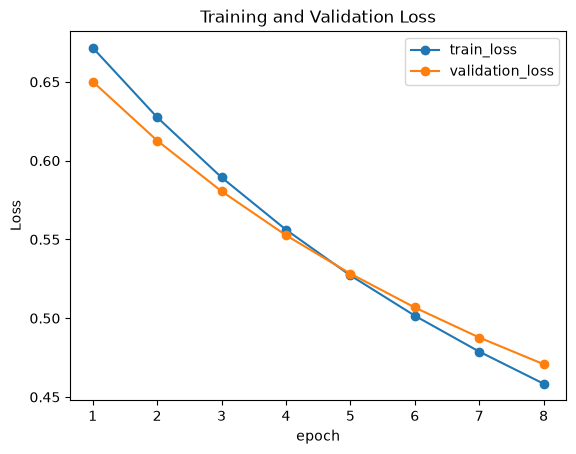

In [23]:
history_df.plot(
    x="epoch",
    y=[
        "train_loss",
        "validation_loss",
    ],
    marker="o",
)

plt.title(
    "Training and Validation Loss"
)

plt.ylabel("Loss")
plt.show()

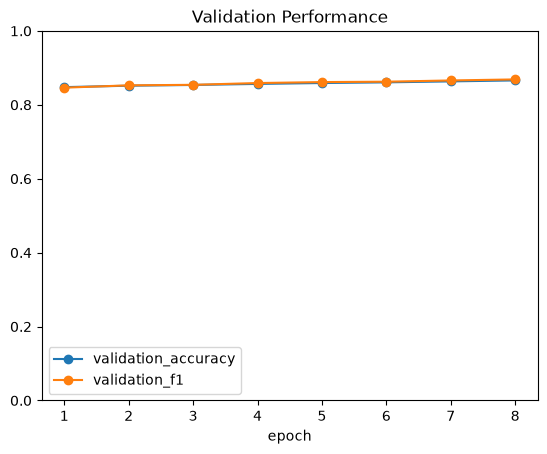

In [24]:
history_df.plot(
    x="epoch",
    y=[
        "validation_accuracy",
        "validation_f1",
    ],
    marker="o",
)

plt.title(
    "Validation Performance"
)

plt.ylim(0, 1)
plt.show()

In [25]:
validation_results = evaluate_model(
    model=model,
    data_loader=validation_loader,
    loss_function=loss_function,
    device=device,
)

print(
    classification_report(
        validation_results["labels"],
        validation_results["predictions"],
        target_names=[
            "Negative",
            "Positive",
        ],
        digits=4,
    )
)

              precision    recall  f1-score   support

    Negative     0.8777    0.8492    0.8632      2467
    Positive     0.8552    0.8827    0.8687      2489

    accuracy                         0.8660      4956
   macro avg     0.8664    0.8659    0.8660      4956
weighted avg     0.8664    0.8660    0.8660      4956



In [26]:
validation_confusion_matrix = confusion_matrix(
    validation_results["labels"],
    validation_results["predictions"],
)

validation_confusion_matrix

array([[2095,  372],
       [ 292, 2197]])

In [27]:
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports" / "baseline"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "number_of_features": X_train.shape[1],
        "best_validation_f1": best_validation_f1,
        "random_seed": RANDOM_SEED,
    },
    MODEL_DIR / "tfidf_pytorch_logistic_regression.pt",
)

joblib.dump(
    vectorizer,
    MODEL_DIR / "tfidf_vectorizer.joblib",
)

history_df.to_csv(
    REPORT_DIR / "training_history.csv",
    index=False,
)

print("Model and vectorizer saved.")

Model and vectorizer saved.
